In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, plot_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

df_original = pd.read_parquet('Imdb_Movie_Dataset.parquet')

FileNotFoundError: [Errno 2] No such file or directory: '../Imdb_Movie_Dataset.parquet'

In [ ]:
LIMIAR_NOTA_MINIMA = 6.8
LIMIAR_VOTOS_MINIMOS = 20
LIMIAR_VOTOS_MAXIMOS = 3000

condicao_nota = df['vote_average'] >= LIMIAR_NOTA_MINIMA
condicao_votos_min = df['vote_count'] >= LIMIAR_VOTOS_MINIMOS
condicao_votos_max = df['vote_count'] <= LIMIAR_VOTOS_MAXIMOS

df['sucesso_nicho'] = (condicao_nota & condicao_votos_min & condicao_votos_max).astype(int)

print("Distribuição da variável-alvo:")
print(df['sucesso_nicho'].value_counts())

Distribuição da variável-alvo:
sucesso_nicho
0    937013
1     14542
Name: count, dtype: int64


In [ ]:
# One-Hot Encoding para a variável 'genres'
df['genres_limpo'] = df['genres'].astype(str).str.replace(r'[\(\)\[\]\']', '', regex=True).str.replace(' ', '')
df_genres = df['genres_limpo'].str.get_dummies(sep=',').add_prefix('genero_')

# Agrupamento de idiomas minoritários e aplicação de One-Hot Encoding
top_idiomas = df['original_language'].value_counts().head(5).index
df['idioma_agrupado'] = df['original_language'].where(df['original_language'].isin(top_idiomas), 'outros')
df_idiomas = pd.get_dummies(df['idioma_agrupado'], prefix='idioma', dtype=int)

# Extração da feature temporal (ano)
df['release_year'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce').dt.year

# Agrupamento das variáveis independentes numéricas
pistas_numericas = df[['runtime', 'revenue', 'release_year']].fillna(0)

# Concatenação do dataframe final de features (X) e isolamento do vetor alvo (y)
X = pd.concat([pistas_numericas, df_genres, df_idiomas], axis=1)
y = df['sucesso_nicho']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)


In [ ]:
# Instanciação do classificador LightGBM
# O parâmetro class_weight='balanced' aplica penalidades inversamente proporcionais às frequências das classes
modelo_lgbm = LGBMClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Ajuste do modelo aos dados de treino
modelo_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 11557, number of negative: 749687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.275492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 704
[LightGBM] [Info] Number of data points in the train set: 761244, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
               random_state=42)

In [ ]:
# Geração de previsões baseadas no conjunto de teste
previsoes_lgbm = modelo_lgbm.predict(X_test)

# Cálculo e exibição das métricas de avaliação
print(f"Acurácia Geral: {accuracy_score(y_test, previsoes_lgbm):.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, previsoes_lgbm, digits=4))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, previsoes_lgbm))

Acurácia Geral: 0.8173

Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.9976    0.8164    0.8979    187326
           1     0.0706    0.8750    0.1306      2985

    accuracy                         0.8173    190311
   macro avg     0.5341    0.8457    0.5143    190311
weighted avg     0.9830    0.8173    0.8859    190311


Matriz de Confusão:
[[152932  34394]
 [   373   2612]]


<Figure size 1000x600 with 0 Axes>

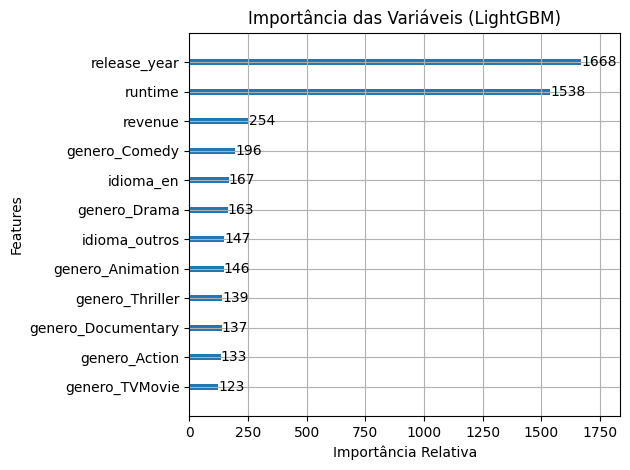

Execução finalizada. Modelo salvo como 'lgbm_sucesso_nicho_model.pkl'.


In [ ]:
# Geração do gráfico de Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(modelo_lgbm, max_num_features=12, title="Importância das Variáveis (LightGBM)", xlabel="Importância Relativa", ylabel="Features")
plt.tight_layout()
plt.show()

# Serialização do modelo treinado para armazenamento local
nome_do_modelo = 'lgbm_sucesso_nicho_model.pkl'
joblib.dump(modelo_lgbm, 'models/lgbm_sucesso_nicho_model.pkl')
print(f"Execução finalizada. Modelo salvo como '{nome_do_modelo}'.")